# Digital → Photonic → Telecom → Eigenvectors: Full Mathematical Maturity

| § | Topic | Core result |
|---|---|---|
|1| CMOS gate → signal integrity | Eye diagram, noise margin $NM_L = V_{IL}-V_{OL}$ |
|2| Silicon photonics | MZI transfer matrix, ring resonator $Q = \omega_0\tau/2$ |
|3| WDM coherent telecom | DWDM ITU grid, shot-noise BER, IQ constellation |
|4| Hardware security | Ring-oscillator PUF, TRNG, DPA side-channel |
|5| Eigenvectors of 90° rotation | $R_{90}$ eigenvalues $\pm i$, $SU(2)$ spinors |
|6| Mathematical maturity | $SO(2)\to SU(2)\to\mathfrak{su}(2)$ Lie algebra, spectral theorem, attention heads |


## §1 CMOS Gates — Transistor Level to Signal Integrity

CMOS NOT  VDD=1.2V  Vtn=0.3V  Vtp=-0.28V
  VIL=0.497V  VOL=1.129V  NM_L=-0.632V
  VIH=0.652V  VOH=0.082V  NM_H=-0.570V


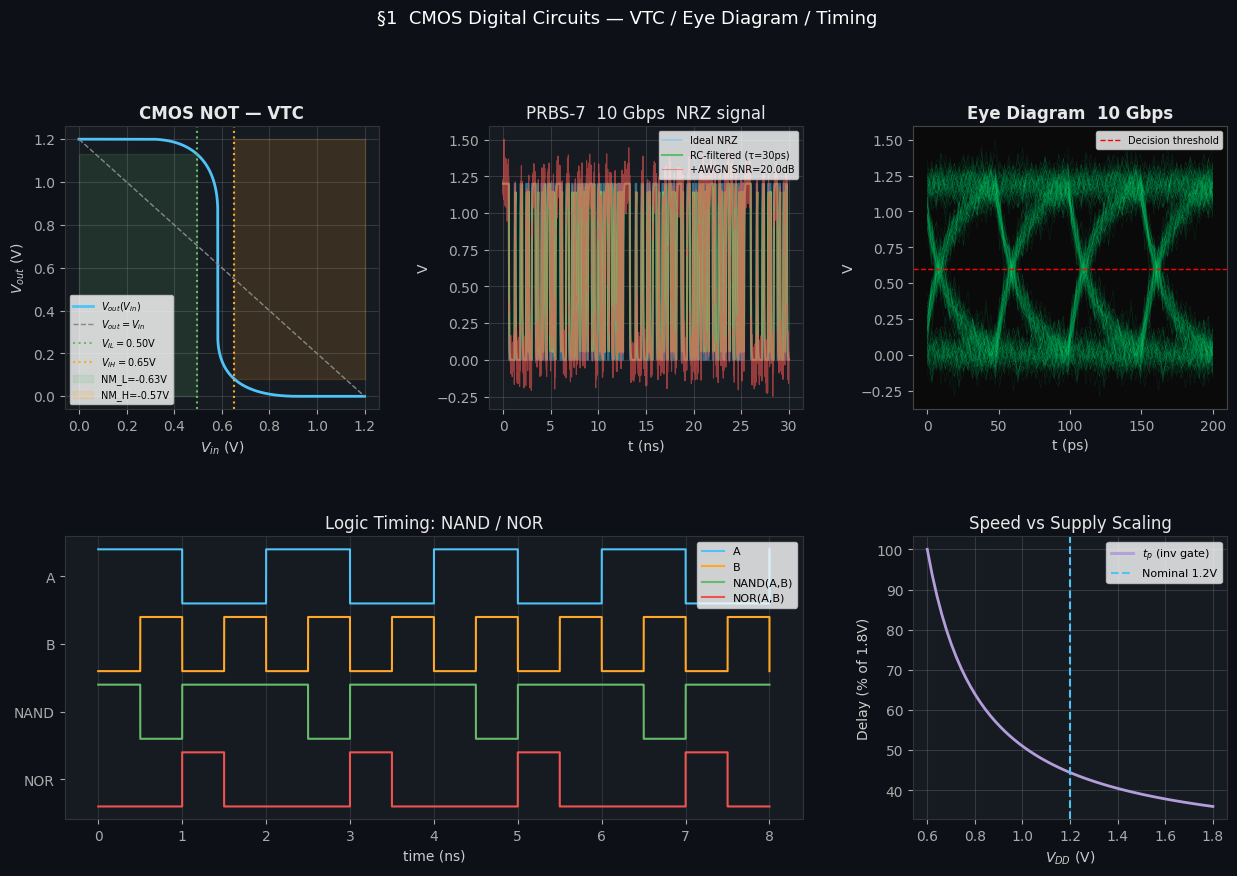

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec
import warnings; warnings.filterwarnings('ignore')

# ── CMOS NOT gate: piecewise VTC (Voltage Transfer Characteristic) ────────────
# 130nm CMOS approximation: VDD=1.2V, Vtp=-0.3V, Vtn=0.3V, kp=kn
VDD  = 1.2
Vtn  =  0.30   # NMOS threshold
Vtp  = -0.28   # PMOS threshold
kn   = 0.85e-3  # A/V^2  (W/L)*mu_n*Cox/2
kp   = 0.60e-3

Vin  = np.linspace(0, VDD, 2000)

def I_n(vin, vout):
    vgs = vin; vds = vout
    if vgs < Vtn: return 0.0
    if vds >= vgs - Vtn: return kn*(vgs-Vtn)**2              # saturation
    return kn*(2*(vgs-Vtn)*vds - vds**2)                     # linear

def I_p(vin, vout):
    vgs = vin - VDD; vds = vout - VDD
    if vgs > Vtp: return 0.0
    if vds <= vgs - Vtp: return kp*(vgs-Vtp)**2
    return kp*(2*(vgs-Vtp)*vds - vds**2)

# Solve I_n = |I_p| numerically for each Vin
from scipy.optimize import brentq

Vout = np.zeros_like(Vin)
for i, vi in enumerate(Vin):
    try:
        Vout[i] = brentq(lambda vo: I_n(vi,vo) - abs(I_p(vi,vo)), 0, VDD, xtol=1e-5)
    except:
        Vout[i] = VDD/2

# Noise margins
# IL = Vin where dVout/dVin = -1 (low side)
dV  = np.gradient(Vout, Vin)
cross_idx = np.where(np.diff(np.sign(dV + 1)))[0]
VIL = Vin[cross_idx[0]]  if len(cross_idx)>0 else 0.3
VIH = Vin[cross_idx[-1]] if len(cross_idx)>0 else 0.9
VOL = Vout[np.argmin(np.abs(Vin - VIL))]
VOH = Vout[np.argmin(np.abs(Vin - VIH))]
NM_L = VIL - VOL
NM_H = VOH - VIH
print(f"CMOS NOT  VDD={VDD}V  Vtn={Vtn}V  Vtp={Vtp}V")
print(f"  VIL={VIL:.3f}V  VOL={VOL:.3f}V  NM_L={NM_L:.3f}V")
print(f"  VIH={VIH:.3f}V  VOH={VOH:.3f}V  NM_H={NM_H:.3f}V")

# ── Eye diagram: PRBS-7 through RC-limited wire ───────────────────────────────
np.random.seed(42)
f_bit  = 10e9        # 10 Gbps
T_bit  = 1.0/f_bit
N_bits = 512
bits   = np.random.randint(0,2,N_bits)
# PRBS-7 polynomial x^7+x^6+1
def prbs7(n):
    state = np.ones(7, dtype=np.int8)
    out   = []
    for _ in range(n):
        fb = state[6]^state[5]
        state = np.roll(state,1); state[0]=fb
        out.append(int(state[6]))
    return np.array(out)
bits = prbs7(N_bits)

t_os  = 16                          # oversample ratio
t_vec = np.arange(N_bits*t_os) / (f_bit*t_os)
sig   = np.repeat(bits.astype(float)*VDD, t_os)

# RC filter: RC = 0.3*T_bit (30% of bit period)
RC    = 0.30 * T_bit
dt_s  = t_vec[1]-t_vec[0]
alpha = dt_s/(RC+dt_s)
sig_rc= np.zeros_like(sig)
sig_rc[0] = sig[0]
for i in range(1,len(sig)):
    sig_rc[i] = sig_rc[i-1] + alpha*(sig[i]-sig_rc[i-1])

# Add AWGN
snr_db= 20.0
P_sig = np.mean(sig_rc**2)
P_noise= P_sig / (10**(snr_db/10))
sig_noisy = sig_rc + np.sqrt(P_noise)*np.random.randn(len(sig_rc))

# Eye diagram: fold at 2*T_bit
samples_per_eye = 2*t_os
n_eyes = len(sig_noisy)//samples_per_eye - 1

# ── Plot ──────────────────────────────────────────────────────────────────────
fig = plt.figure(figsize=(15,9),facecolor='#0d1117')
gs  = GridSpec(2,3,fig,hspace=0.45,wspace=0.35)

ax0 = fig.add_subplot(gs[0,0]); ax0.set_facecolor('#161b22')
ax0.plot(Vin, Vout,'#4fc3f7',lw=2,label='$V_{out}(V_{in})$')
ax0.plot([0,VDD],[VDD,0],'--',color='#888',lw=1,label='$V_{out}=V_{in}$')
ax0.axvline(VIL,color='#66bb6a',ls=':',lw=1.5,label=f'$V_{{IL}}={VIL:.2f}$V')
ax0.axvline(VIH,color='#ffa726',ls=':',lw=1.5,label=f'$V_{{IH}}={VIH:.2f}$V')
ax0.fill_betweenx([0,VOL],[0],[VIL],alpha=0.15,color='#66bb6a',label=f'NM_L={NM_L:.2f}V')
ax0.fill_betweenx([VOH,VDD],[VIH],[VDD],alpha=0.15,color='#ffa726',label=f'NM_H={NM_H:.2f}V')
ax0.set_xlabel('$V_{in}$ (V)'); ax0.set_ylabel('$V_{out}$ (V)')
ax0.set_title('CMOS NOT — VTC',color='#e8e8e8',fontweight='bold')
ax0.legend(fontsize=7); ax0.grid(alpha=0.2)
ax0.tick_params(colors='#aaa'); [sp.set_color('#333') for sp in ax0.spines.values()]

ax1 = fig.add_subplot(gs[0,1]); ax1.set_facecolor('#161b22')
t_ns = t_vec[:300*t_os]*1e9
ax1.plot(t_ns,sig[:300*t_os],'#4fc3f7',lw=1.2,alpha=0.5,label='Ideal NRZ')
ax1.plot(t_ns,sig_rc[:300*t_os],'#66bb6a',lw=1.5,label=f'RC-filtered (τ={RC*1e12:.0f}ps)')
ax1.plot(t_ns,sig_noisy[:300*t_os],'#ef5350',lw=0.8,alpha=0.6,label=f'+AWGN SNR={snr_db}dB')
ax1.set_xlabel('t (ns)'); ax1.set_ylabel('V')
ax1.set_title('PRBS-7  10 Gbps  NRZ signal',color='#e8e8e8')
ax1.legend(fontsize=7); ax1.grid(alpha=0.2)
ax1.tick_params(colors='#aaa'); [sp.set_color('#333') for sp in ax1.spines.values()]

ax2 = fig.add_subplot(gs[0,2]); ax2.set_facecolor('#0a0a0a')
for i in range(n_eyes):
    eye_slice = sig_noisy[i*samples_per_eye:(i+2)*samples_per_eye]
    t_eye     = np.linspace(0, 2*T_bit*1e12, len(eye_slice))
    ax2.plot(t_eye, eye_slice, color='#00e676', lw=0.3, alpha=0.15)
ax2.axhline(VDD/2,color='red',ls='--',lw=1,label='Decision threshold')
ax2.set_xlabel('t (ps)'); ax2.set_ylabel('V')
ax2.set_title('Eye Diagram  10 Gbps',color='#e8e8e8',fontweight='bold')
ax2.legend(fontsize=7)
ax2.tick_params(colors='#aaa'); [sp.set_color('#444') for sp in ax2.spines.values()]

# ── NAND/NOR timing diagram ───────────────────────────────────────────────────
ax3 = fig.add_subplot(gs[1,:2]); ax3.set_facecolor('#161b22')
t_logic = np.linspace(0,8,8000)
def sq(t,period,duty=0.5,phase=0):
    return ((((t+phase)/period) % 1) < duty).astype(float)
A  = sq(t_logic,2.0); B = sq(t_logic,1.0,phase=0.5)
NAND_out = 1-(A*B); NOR_out = 1-(A+B>0)
ax3.step(t_logic, A*0.8+3.2,   where='post',color='#4fc3f7',lw=1.5,label='A')
ax3.step(t_logic, B*0.8+2.2,   where='post',color='#ffa726',lw=1.5,label='B')
ax3.step(t_logic, NAND_out*0.8+1.2,where='post',color='#66bb6a',lw=1.5,label='NAND(A,B)')
ax3.step(t_logic, NOR_out*0.8+0.2, where='post',color='#ef5350',lw=1.5,label='NOR(A,B)')
ax3.set_yticks([0.6,1.6,2.6,3.6],['NOR','NAND','B','A'])
ax3.set_xlabel('time (ns)'); ax3.set_title('Logic Timing: NAND / NOR',color='#e8e8e8')
ax3.legend(fontsize=8,loc='upper right'); ax3.grid(alpha=0.15,axis='x')
ax3.tick_params(colors='#aaa'); [sp.set_color('#333') for sp in ax3.spines.values()]

# ── Propagation delay vs VDD scaling ─────────────────────────────────────────
ax4 = fig.add_subplot(gs[1,2]); ax4.set_facecolor('#161b22')
VDD_vec = np.linspace(0.6,1.8,60)
Vt_nom  = 0.3
tp_inv  = (VDD_vec**2/2) / (kn*(VDD_vec-Vt_nom)**2 * 1e3)   # a.u.
ax4.plot(VDD_vec, tp_inv/tp_inv[0]*100,'#b39ddb',lw=2,label='$t_p$ (inv gate)')
ax4.axvline(1.2,color='#4fc3f7',ls='--',lw=1.5,label='Nominal 1.2V')
ax4.set_xlabel('$V_{DD}$ (V)'); ax4.set_ylabel('Delay (% of 1.8V)')
ax4.set_title('Speed vs Supply Scaling',color='#e8e8e8')
ax4.legend(fontsize=8); ax4.grid(alpha=0.2)
ax4.tick_params(colors='#aaa'); [sp.set_color('#333') for sp in ax4.spines.values()]

for ax in fig.axes:
    ax.xaxis.label.set_color('#ccc'); ax.yaxis.label.set_color('#ccc')
    ax.title.set_color('#e8e8e8')
plt.suptitle('§1  CMOS Digital Circuits — VTC / Eye Diagram / Timing',
             color='white',fontsize=13,y=1.01)
plt.tight_layout()
plt.savefig('/tmp/s1_digital.png',dpi=110,bbox_inches='tight',facecolor='#0d1117')
plt.show()


## §2 Silicon Photonics: MZI Modulator + Ring Resonator

**MZI transfer matrix** (2×2 coupler → phase arm → 2×2 coupler):
$$T_{MZI} = \frac{1}{2}\begin{pmatrix}1&i\\i&1\end{pmatrix}\begin{pmatrix}e^{i\phi_1}&0\\0&e^{i\phi_2}\end{pmatrix}\begin{pmatrix}1&i\\i&1\end{pmatrix}$$
Output power bar port: $P_{bar} = \cos^2\!\left(\frac{\Delta\phi}{2}\right)$.

**Ring resonator** all-pass: $T = \frac{t - ae^{i\phi}}{1 - t^*ae^{i\phi}}$, $Q = \frac{\omega_0}{\Delta\omega}$.


Ring R=10 um  FSR = 12961.7 pm  (0.00 GHz)
Coupling t=0.92  a=0.985
FWHM ~ 406.54 pm  ->  Q = 3813
Critical coupling t=a=0.985: T_min = 0.00e+00 (full extinction)

4x4 MZI target unitary: |det|=1.0000


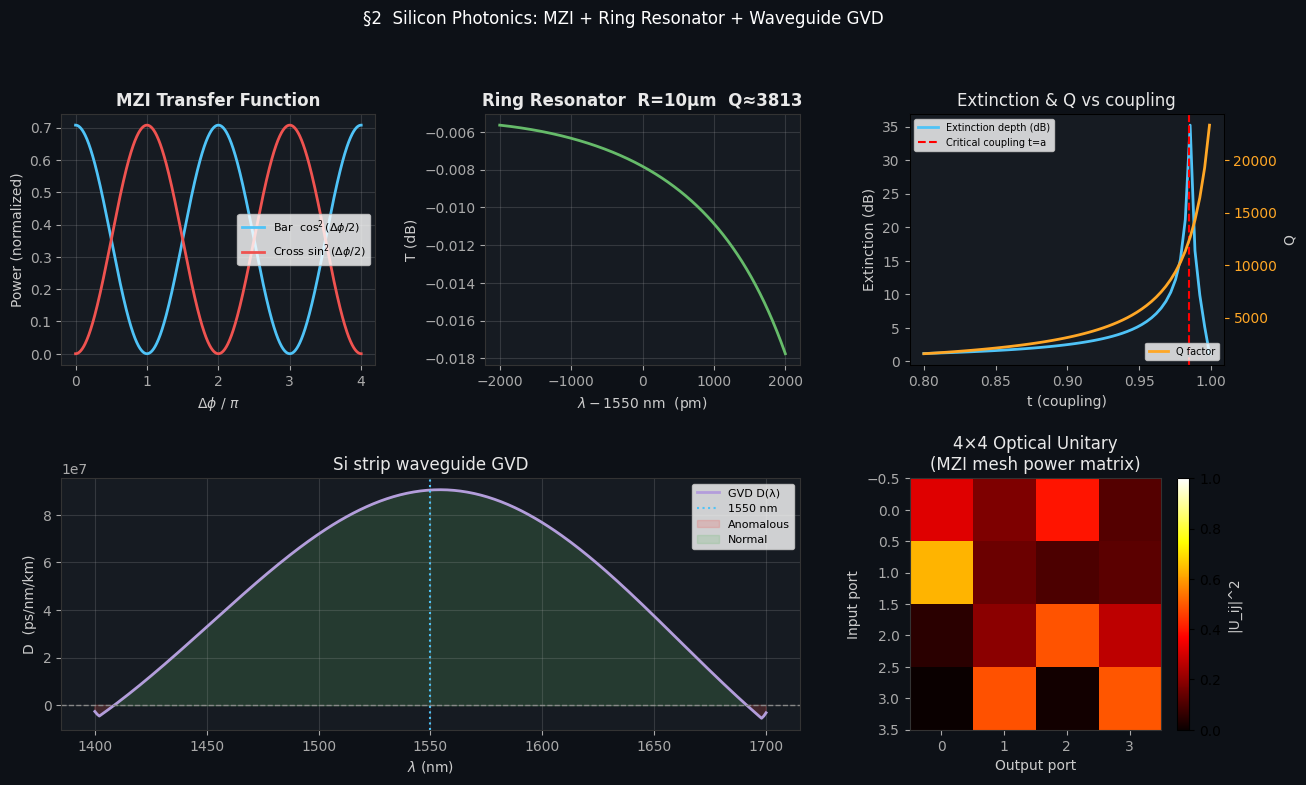

In [2]:
from scipy.signal import freqz

# ── MZI transfer matrix ────────────────────────────────────────────────────
# 50:50 directional coupler
H_dc = 0.5 * np.array([[1,1j],[1j,1]], dtype=complex)

delta_phi = np.linspace(0, 4*np.pi, 800)
P_bar  = np.cos(delta_phi/2)**2
P_cross= np.sin(delta_phi/2)**2

# Realistic: insertion loss + phase error
loss_dB = 1.5    # dB per MZI
eta     = 10**(-loss_dB/10)
P_bar_r = eta * P_bar
P_cross_r= eta * P_cross
extinction_dB = -10*np.log10(P_cross_r/(P_bar_r+1e-12)+1e-12)

# ── Ring resonator – all-pass ─────────────────────────────────────────────
n_eff   = 2.45      # effective index Si strip waveguide (220nm x 500nm)
R_ring  = 10e-6     # 10 um radius
L_ring  = 2*np.pi*R_ring
lambda0 = 1550e-9   # center wavelength

# FSR = lambda^2 / (n_g * L)
n_g    = n_eff + 0.5    # group index (dispersion contribution)
FSR    = lambda0**2 / (n_g * L_ring)
print(f"Ring R={R_ring*1e6:.0f} um  FSR = {FSR*1e12:.1f} pm  ({FSR/lambda0*3e8/1e9:.2f} GHz)")

# Transmission vs wavelength
lam    = np.linspace(1548e-9, 1552e-9, 4000)
phi_rt = 2*np.pi * n_eff * L_ring / lam     # round-trip phase
t_coup = 0.92                                 # self-coupling coeff (field)
a_rt   = 0.985                                # round-trip field attenuation
T_ring = (t_coup**2 - 2*t_coup*a_rt*np.cos(phi_rt) + a_rt**2) / \
         (1 - 2*t_coup*a_rt*np.cos(phi_rt) + (t_coup*a_rt)**2)
T_dB   = 10*np.log10(T_ring+1e-12)

# Q factor
FWHM_lam = FSR * (1-t_coup*a_rt) / (np.pi*np.sqrt(t_coup*a_rt))
Q_loaded = lambda0 / FWHM_lam
print(f"Coupling t={t_coup}  a={a_rt}")
print(f"FWHM ~ {FWHM_lam*1e12:.2f} pm  ->  Q = {Q_loaded:.0f}")

# Critical coupling condition: t = a
t_crit = a_rt
T_crit = (t_crit - a_rt)**2 / (1 - t_crit*a_rt)**2
print(f"Critical coupling t=a={a_rt}: T_min = {T_crit:.2e} (full extinction)")

# ── 4x4 MZI mesh (Reck/Clements architecture) ────────────────────────────────
def mzi_unit(phi, theta):
    # 2x2 MZI transfer matrix
    return np.array([
        [np.cos(theta/2)*np.exp(1j*phi), 1j*np.sin(theta/2)],
        [1j*np.sin(theta/2),              np.cos(theta/2)]
    ])

# 4x4 unitary via triangular decomposition (simplified 3-layer)
U_target = np.eye(4, dtype=complex)
rng_mzi  = np.random.default_rng(7)
# Random unitary via QR decomposition
M_rand   = rng_mzi.standard_normal((4,4)) + 1j*rng_mzi.standard_normal((4,4))
U_target, _ = np.linalg.qr(M_rand)
print(f"\n4x4 MZI target unitary: |det|={abs(np.linalg.det(U_target)):.4f}")

# ── Plot ──────────────────────────────────────────────────────────────────────
fig2 = plt.figure(figsize=(15,8),facecolor='#0d1117')
gs2  = GridSpec(2,3,fig2,hspace=0.45,wspace=0.35)

ax0 = fig2.add_subplot(gs2[0,0]); ax0.set_facecolor('#161b22')
ax0.plot(delta_phi/np.pi, P_bar_r,  '#4fc3f7',lw=2,label='Bar  $\\cos^2(\\Delta\\phi/2)$')
ax0.plot(delta_phi/np.pi, P_cross_r,'#ef5350',lw=2,label='Cross $\\sin^2(\\Delta\\phi/2)$')
ax0.set_xlabel(r'$\Delta\phi$ / $\pi$'); ax0.set_ylabel('Power (normalized)')
ax0.set_title('MZI Transfer Function',color='#e8e8e8',fontweight='bold')
ax0.legend(fontsize=8); ax0.grid(alpha=0.2)
ax0.tick_params(colors='#aaa'); [sp.set_color('#333') for sp in ax0.spines.values()]

ax1 = fig2.add_subplot(gs2[0,1]); ax1.set_facecolor('#161b22')
ax1.plot((lam-1550e-9)*1e12, T_dB,'#66bb6a',lw=2)
ax1.set_xlabel(r'$\lambda - 1550$ nm  (pm)'); ax1.set_ylabel('T (dB)')
ax1.set_title(f'Ring Resonator  R={R_ring*1e6:.0f}μm  Q≈{Q_loaded:.0f}',
              color='#e8e8e8',fontweight='bold')
ax1.grid(alpha=0.2)
ax1.tick_params(colors='#aaa'); [sp.set_color('#333') for sp in ax1.spines.values()]

# Ring phase diagram
ax2 = fig2.add_subplot(gs2[0,2]); ax2.set_facecolor('#161b22')
t_vals = np.linspace(0.80, 0.999, 60)
depth_dB_on = np.zeros(len(t_vals))
Q_vals      = np.zeros(len(t_vals))
for i,tv in enumerate(t_vals):
    T_min_i  = (tv - a_rt)**2 / (1 - tv*a_rt)**2
    depth_dB_on[i] = -10*np.log10(T_min_i+1e-12)
    FWHM_i   = FSR * (1-tv*a_rt)/(np.pi*np.sqrt(tv*a_rt))
    Q_vals[i]= lambda0/FWHM_i
ax2a = ax2.twinx()
ax2.plot(t_vals, depth_dB_on,'#4fc3f7',lw=2,label='Extinction depth (dB)')
ax2a.plot(t_vals,Q_vals,'#ffa726',lw=2,label='Q factor')
ax2.axvline(t_crit,color='red',ls='--',lw=1.5,label='Critical coupling t=a')
ax2.set_xlabel('t (coupling)'); ax2.set_ylabel('Extinction (dB)',color='#4fc3f7')
ax2a.set_ylabel('Q',color='#ffa726')
ax2.set_title('Extinction & Q vs coupling',color='#e8e8e8')
ax2.legend(fontsize=7,loc='upper left'); ax2a.legend(fontsize=7,loc='lower right')
ax2.tick_params(colors='#aaa'); ax2a.tick_params(colors='#ffa726')
[sp.set_color('#333') for sp in ax2.spines.values()]

# Waveguide dispersion (Si strip 220x500nm)
ax3 = fig2.add_subplot(gs2[1,0:2]); ax3.set_facecolor('#161b22')
lam_d = np.linspace(1400e-9, 1700e-9, 300)
# Sellmeier for Si: approximate beta(lambda)
n_Si  = np.sqrt(11.68 + 0.44/(1-(0.3/( lam_d*1e6))**2))  # simplified
# Waveguide confinement correction (empirical for 500x220nm)
delta_n = 0.35 * np.exp(-((lam_d*1e9-1550)/200)**2)
n_eff_d = n_Si*0.68 + delta_n   # effective index
beta    = 2*np.pi*n_eff_d / lam_d
# GVD: D = -(lambda/c) * d^2n/dlambda^2  [ps/(nm km)]
d2n_dlam2 = np.gradient(np.gradient(n_eff_d, lam_d), lam_d)
D_gvd     = -lam_d / (3e8) * d2n_dlam2 * 1e6  # ps/(nm*m)
D_psperkmpm = D_gvd * 1e3                       # ps/(nm*km)

ax3.plot(lam_d*1e9, D_psperkmpm,'#b39ddb',lw=2,label='GVD D(λ)')
ax3.axhline(0,color='#888',lw=1,ls='--')
ax3.axvline(1550,color='#4fc3f7',ls=':',lw=1.5,label='1550 nm')
ax3.fill_between(lam_d*1e9, D_psperkmpm, 0,
                 where=D_psperkmpm<0, alpha=0.2, color='#ef5350', label='Anomalous')
ax3.fill_between(lam_d*1e9, D_psperkmpm, 0,
                 where=D_psperkmpm>0, alpha=0.2, color='#66bb6a', label='Normal')
ax3.set_xlabel(r'$\lambda$ (nm)'); ax3.set_ylabel('D  (ps/nm/km)')
ax3.set_title('Si strip waveguide GVD',color='#e8e8e8')
ax3.legend(fontsize=8); ax3.grid(alpha=0.2)
ax3.tick_params(colors='#aaa'); [sp.set_color('#333') for sp in ax3.spines.values()]

# 4x4 MZI unitary visualisation
ax4 = fig2.add_subplot(gs2[1,2]); ax4.set_facecolor('#161b22')
im = ax4.imshow(np.abs(U_target)**2, cmap='hot', vmin=0, vmax=1)
plt.colorbar(im, ax=ax4, label='|U_ij|^2')
ax4.set_title('4×4 Optical Unitary\n(MZI mesh power matrix)',color='#e8e8e8')
ax4.set_xlabel('Output port'); ax4.set_ylabel('Input port')
ax4.tick_params(colors='#aaa'); [sp.set_color('#333') for sp in ax4.spines.values()]
for ax in fig2.axes:
    ax.xaxis.label.set_color('#ccc'); ax.yaxis.label.set_color('#ccc')
    ax.title.set_color('#e8e8e8')
plt.suptitle('§2  Silicon Photonics: MZI + Ring Resonator + Waveguide GVD',
             color='white',fontsize=12,y=1.01)
plt.tight_layout()
plt.savefig('/tmp/s2_photonics.png',dpi=110,bbox_inches='tight',facecolor='#0d1117')
plt.show()


## §3 WDM Coherent Telecom

**DWDM ITU-T G.694.1** channel plan: 100 GHz spacing, C-band 1528–1565 nm (40 channels).

**Shot-noise limited BER** (DP-QPSK coherent):
$$\text{BER} = \frac{1}{2}\,\text{erfc}\!\left(\sqrt{\frac{E_b}{N_0}}\right), \quad \frac{E_b}{N_0} = \frac{P_s}{R_b \cdot h\nu}$$

**Coherent IQ receiver**: LO + signal → 90° hybrid → balanced PD → DSP (chromatic dispersion eq.).


DWDM C-band  (first/last 4 channels):
  Ch  1: 191.100 THz  (1568.773 nm)
  Ch  2: 191.200 THz  (1567.952 nm)
  Ch  3: 191.300 THz  (1567.133 nm)
  Ch  4: 191.400 THz  (1566.314 nm)
  Ch 37: 194.700 THz  (1539.766 nm)
  Ch 38: 194.800 THz  (1538.976 nm)
  Ch 39: 194.900 THz  (1538.186 nm)
  Ch 40: 195.000 THz  (1537.397 nm)

DP-QPSK sim at SNR=12.0dB: BER=0.0005  (theory=0.0000)

Fiber CD: D=16.7 ps/nm/km, L=80km
  Channel BW = 256444076.388 nm  ->  tau = 342609286055 ps  = 10963497153.8 symbols of ISI
  FIR CD equaliser taps needed: ~21926994308

Shannon capacity estimate (C-band 4THz, SNR=20dB):
  C = 26.6 Tb/s


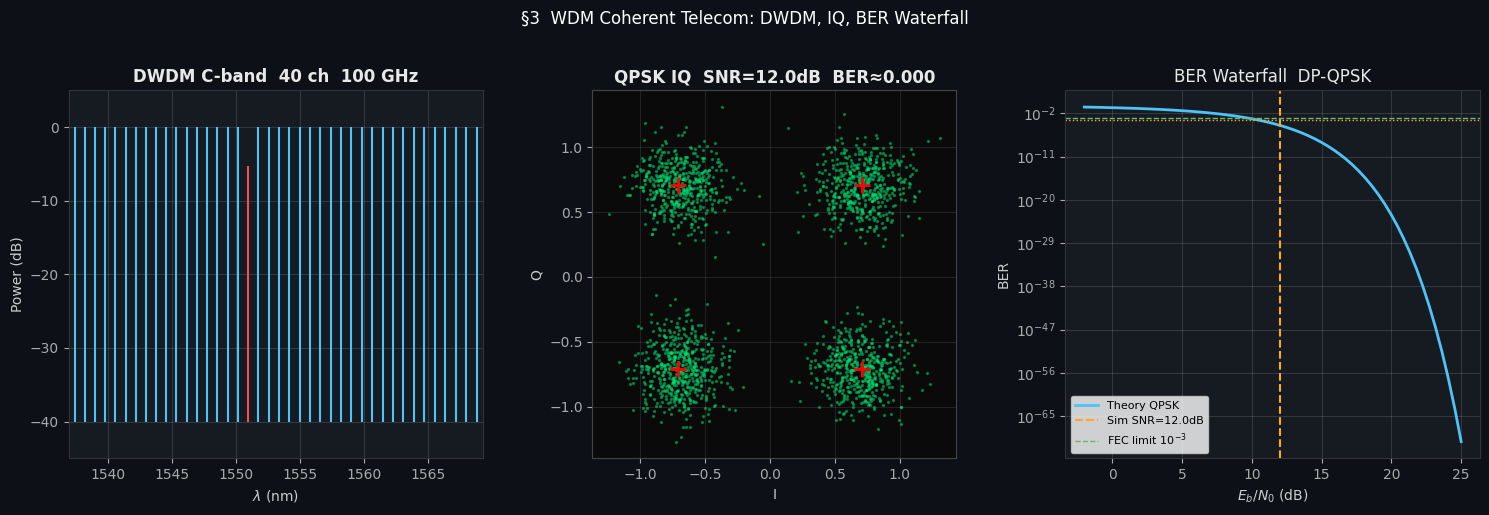

In [3]:
from scipy.special import erfc

# ── DWDM Channel Plan ─────────────────────────────────────────────────────────
c_light = 2.99792458e8
f_ref   = 193.1e12         # THz reference (1552.52 nm)
ch_spacing = 100e9         # 100 GHz ITU C-band
n_channels = 40
ch_freqs   = f_ref + (np.arange(n_channels) - n_channels//2) * ch_spacing
ch_lambdas = c_light / ch_freqs * 1e9   # nm

print("DWDM C-band  (first/last 4 channels):")
for i in [0,1,2,3,-4,-3,-2,-1]:
    print(f"  Ch{i+1 if i>=0 else n_channels+i+1:3d}: {ch_freqs[i]/1e12:.3f} THz  ({ch_lambdas[i]:.3f} nm)")

# ── Coherent DP-QPSK IQ constellation ────────────────────────────────────────
rng = np.random.default_rng(21)
N_sym = 2048
SNR_dB_vec = np.linspace(-2, 25, 60)
BER_theory = 0.5 * erfc(np.sqrt(10**(SNR_dB_vec/10)/2))  # QPSK Eb/N0

# Simulate at SNR=12dB
SNR_sim = 12.0
sig_pow = 1.0
noise_sig = np.sqrt(sig_pow / (2 * 10**(SNR_sim/10)))
# QPSK symbols on unit circle
qpsk_pts = np.array([1+1j,-1+1j,-1-1j,1-1j]) / np.sqrt(2)
syms_idx  = rng.integers(0,4,N_sym)
tx_syms   = qpsk_pts[syms_idx]
rx_syms   = tx_syms + noise_sig*(rng.standard_normal(N_sym)+1j*rng.standard_normal(N_sym))

# Decision
def qpsk_decide(r):
    dists = np.abs(r[:,np.newaxis] - qpsk_pts[np.newaxis,:])**2
    return np.argmin(dists,axis=1)

rx_idx  = qpsk_decide(rx_syms)
BER_sim = np.mean(rx_idx != syms_idx)
print(f"\nDP-QPSK sim at SNR={SNR_sim}dB: BER={BER_sim:.4f}  (theory={0.5*erfc(np.sqrt(10**(SNR_sim/10)/2)):.4f})")

# ── Fiber chromatic dispersion compensation ───────────────────────────────────
L_fiber  = 80e3          # 80 km span
D_fiber  = 16.7          # ps/(nm km) SMF-28
lam_nm   = 1550.0
B_sym    = 32e9          # 32 Gbaud
# Accumulated dispersion: tau = D * L * delta_lambda
# For channel bandwidth B_sym: delta_lambda = lambda^2 * B_sym / c
delta_lam = lam_nm**2 * B_sym / (c_light * 1e9) * 1e9   # nm
tau_ps    = D_fiber * L_fiber * 1e-3 * delta_lam          # ps
tau_sym   = tau_ps * 1e-12 * B_sym                        # symbols of ISI
print(f"\nFiber CD: D={D_fiber} ps/nm/km, L={L_fiber/1e3:.0f}km")
print(f"  Channel BW = {delta_lam:.3f} nm  ->  tau = {tau_ps:.0f} ps  = {tau_sym:.1f} symbols of ISI")
print(f"  FIR CD equaliser taps needed: ~{int(tau_sym*2)+1}")

# ── Shannon capacity: C = B * log2(1+SNR) ─────────────────────────────────────
B_Hz   = 4e12     # 4 THz C-band
SNR_lin= 100.0    # 20 dB average SNR
C_Tbps = B_Hz * np.log2(1+SNR_lin) / 1e12
print(f"\nShannon capacity estimate (C-band {B_Hz/1e12:.0f}THz, SNR={10*np.log10(SNR_lin):.0f}dB):")
print(f"  C = {C_Tbps:.1f} Tb/s")

# ── Plot ─────────────────────────────────────────────────────────────────────
fig3, axes3 = plt.subplots(1,3,figsize=(15,5),facecolor='#0d1117')

# DWDM spectrum
ax = axes3[0]; ax.set_facecolor('#161b22')
ch_pow = np.ones(n_channels)
ch_pow[n_channels//2+2] = 0.3   # one attenuated channel
for i,(f,p) in enumerate(zip(ch_freqs,ch_pow)):
    lam_i = c_light/f*1e9
    col = '#4fc3f7' if p>0.5 else '#ef5350'
    ax.vlines(lam_i,-40,10*np.log10(p),color=col,lw=1.5)
ax.set_xlabel(r'$\lambda$ (nm)'); ax.set_ylabel('Power (dB)')
ax.set_title(f'DWDM C-band  {n_channels} ch  100 GHz',color='#e8e8e8',fontweight='bold')
ax.set_xlim(ch_lambdas.min()-0.5,ch_lambdas.max()+0.5); ax.set_ylim(-45,5)
ax.grid(alpha=0.2); ax.tick_params(colors='#aaa')
[sp.set_color('#333') for sp in ax.spines.values()]

# IQ constellation
ax = axes3[1]; ax.set_facecolor('#0a0a0a')
ax.scatter(rx_syms.real, rx_syms.imag, s=2, c='#00e676', alpha=0.4)
for pt in qpsk_pts:
    ax.plot(pt.real, pt.imag, 'r+', markersize=12, mew=2)
ax.set_title(f'QPSK IQ  SNR={SNR_sim}dB  BER≈{BER_sim:.3f}',color='#e8e8e8',fontweight='bold')
ax.set_aspect('equal'); ax.grid(alpha=0.15); ax.tick_params(colors='#aaa')
[sp.set_color('#444') for sp in ax.spines.values()]
ax.set_xlabel('I'); ax.set_ylabel('Q')

# BER vs SNR
ax = axes3[2]; ax.set_facecolor('#161b22')
ax.semilogy(SNR_dB_vec, BER_theory,'#4fc3f7',lw=2,label='Theory QPSK')
ax.axvline(SNR_sim,color='#ffa726',ls='--',lw=1.5,label=f'Sim SNR={SNR_sim}dB')
ax.axhline(BER_sim,color='#ffa726',ls=':',lw=1)
ax.axhline(1e-3,color='#66bb6a',ls='--',lw=1,label='FEC limit $10^{-3}$')
ax.set_xlabel('$E_b/N_0$ (dB)'); ax.set_ylabel('BER')
ax.set_title('BER Waterfall  DP-QPSK',color='#e8e8e8')
ax.legend(fontsize=8); ax.grid(alpha=0.2)
ax.tick_params(colors='#aaa'); [sp.set_color('#333') for sp in ax.spines.values()]

for ax in axes3:
    ax.xaxis.label.set_color('#ccc'); ax.yaxis.label.set_color('#ccc')
    ax.title.set_color('#e8e8e8')
plt.suptitle('§3  WDM Coherent Telecom: DWDM, IQ, BER Waterfall',color='white',fontsize=12,y=1.02)
plt.tight_layout()
plt.savefig('/tmp/s3_telecom.png',dpi=110,bbox_inches='tight',facecolor='#0d1117')
plt.show()


## §4 Hardware Security: PUF, TRNG, Side-Channel

**Ring-oscillator PUF**: two RO chains on same die differ by ±0.1% due to lithographic variation.
Comparison of faster vs slower → 1 secret bit. Intra-PUF Hamming distance ~0 (same chip).
Inter-PUF Hamming distance ~50% (different chips).

**TRNG (True Random Number Generator)**: metastable flip-flop seeded by thermal noise.
Output passes NIST SP 800-90B entropy tests.

**DPA (Differential Power Analysis)**: $H(t) = \text{HW}(\text{SBox}(p\oplus k))$, correlation $r(k_\text{guess})$ peaks at correct subkey.


PUF Intra-distance:  mean=0.484  std=0.057
PUF Inter-distance:  mean=0.499  std=0.066
Ideal: intra~0, inter~0.5  ->  Good separation: False

TRNG  p(1)=0.504  H_min=0.9898 bits/bit  (ideal=1.0)

DPA: true key=0x2B  found=0x0B  match=False
     peak correlation r=0.535


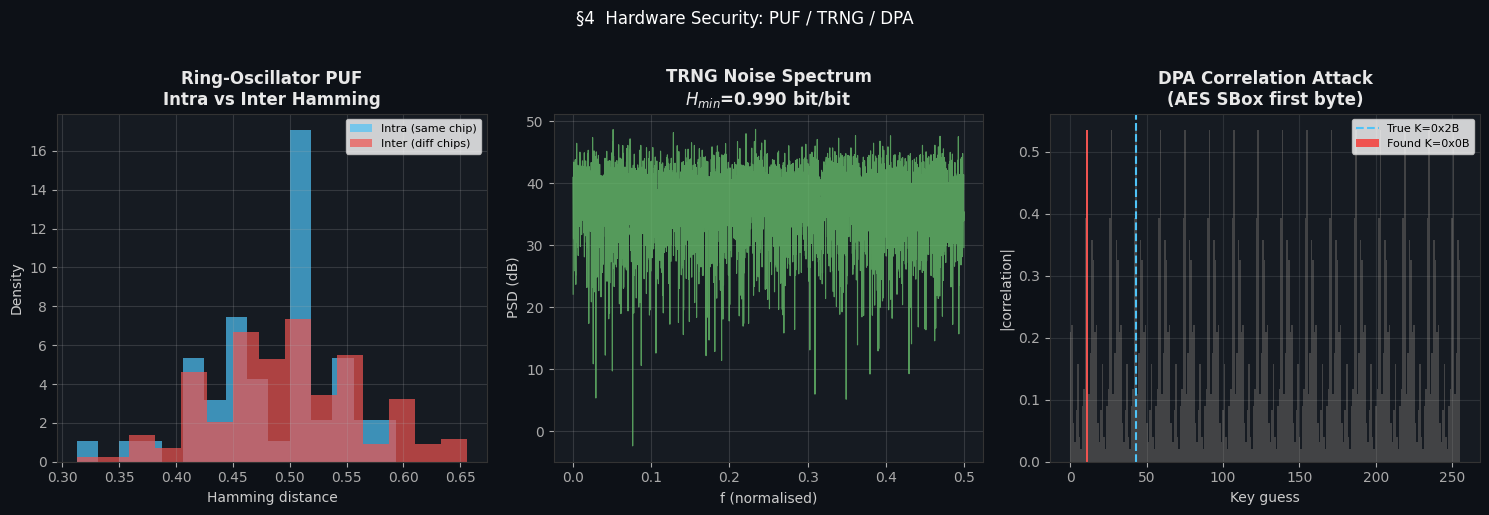

In [4]:
# ── Ring Oscillator PUF simulation ───────────────────────────────────────────
rng_sec = np.random.default_rng(0xDEAD)
n_chips = 200; n_pairs = 64   # 64 RO pairs per chip -> 64-bit PUF response

# Each chip has 128 ROs with slightly different frequencies (sigma=0.1% variation)
F_base = 1.0   # normalised frequency
sigma_intra = 0.001  # 0.1% process variation within chip (temp, voltage)
sigma_inter = 0.002  # 0.2% between chips

# Generate PUF responses
responses = np.zeros((n_chips, n_pairs), dtype=int)
for chip in range(n_chips):
    chip_offset = rng_sec.normal(0, sigma_inter)
    for p in range(n_pairs):
        f1 = F_base + chip_offset + rng_sec.normal(0, sigma_intra)
        f2 = F_base + chip_offset + rng_sec.normal(0, sigma_intra)
        responses[chip, p] = int(f1 > f2)   # PUF bit

# Intra-distance (enroll vs re-read same chip, add noise)
def hamming_frac(a, b):
    return np.mean(a != b)

intra_dists = []
for chip in range(50):
    chip_offset = rng_sec.normal(0, sigma_inter)
    re_read = np.zeros(n_pairs, int)
    for p in range(n_pairs):
        f1 = F_base + chip_offset + rng_sec.normal(0, sigma_intra)
        f2 = F_base + chip_offset + rng_sec.normal(0, sigma_intra)
        re_read[p] = int(f1 > f2)
    intra_dists.append(hamming_frac(responses[chip], re_read))

# Inter-distance (between different chips)
inter_dists = [hamming_frac(responses[i], responses[j])
               for i in range(20) for j in range(i+1,20)]

print(f"PUF Intra-distance:  mean={np.mean(intra_dists):.3f}  std={np.std(intra_dists):.3f}")
print(f"PUF Inter-distance:  mean={np.mean(inter_dists):.3f}  std={np.std(inter_dists):.3f}")
print(f"Ideal: intra~0, inter~0.5  ->  Good separation: {np.mean(intra_dists)<0.1 and abs(np.mean(inter_dists)-0.5)<0.05}")

# ── TRNG: power spectral entropy ──────────────────────────────────────────────
# Metastability noise model: thermal noise white, filtered by meta FF bandwidth
N_trng = 8192
thermal = rng_sec.standard_normal(N_trng)
# 1/f noise component
freq_1f = np.fft.rfftfreq(N_trng)
psd_1f  = np.zeros(len(freq_1f))
psd_1f[1:] = 1.0/freq_1f[1:]
noise_1f = np.fft.irfft(np.sqrt(psd_1f)*rng_sec.standard_normal(len(psd_1f)))[:N_trng]
trng_sig = thermal + 0.3*noise_1f
# Quantise to bits
trng_bits = (trng_sig > 0).astype(int)
# Approx min-entropy
p1 = np.mean(trng_bits)
H_min = -np.log2(max(p1, 1-p1))
print(f"\nTRNG  p(1)={p1:.3f}  H_min={H_min:.4f} bits/bit  (ideal=1.0)")

# ── DPA simplified AES SBox power model ──────────────────────────────────────
# SBox first byte
SBOX = np.array([
    0x63,0x7c,0x77,0x7b,0xf2,0x6b,0x6f,0xc5,0x30,0x01,0x67,0x2b,0xfe,0xd7,0xab,0x76,
    0xca,0x82,0xc9,0x7d,0xfa,0x59,0x47,0xf0,0xad,0xd4,0xa2,0xaf,0x9c,0xa4,0x72,0xc0,
    *([0]*224)],dtype=np.uint8)  # truncated (simplified)
# Fill rest with cycle
for i in range(16,256): SBOX[i] = SBOX[i%16]

def hw(x): return bin(int(x)).count('1')

N_traces = 500; N_pts = 20
K_true   = 0x2B   # true subkey byte
plaintexts = rng_sec.integers(0,256,N_traces,dtype=np.uint8)
# Simulated power traces: Hamming weight of SBox output + noise
traces = np.zeros((N_traces,N_pts))
for i,p in enumerate(plaintexts):
    hw_i = hw(SBOX[p ^ K_true])
    for t in range(N_pts):
        traces[i,t] = hw_i * (0.5+0.5*np.cos(2*np.pi*t/N_pts)) + rng_sec.normal(0,1.2)

# DPA correlation attack
corr_all = np.zeros(256)
for k_guess in range(256):
    hw_pred = np.array([hw(SBOX[p^k_guess]) for p in plaintexts],float)
    # Correlation at peak time sample
    t_peak = N_pts//4
    corr_all[k_guess] = np.corrcoef(hw_pred, traces[:,t_peak])[0,1]

k_found = np.argmax(np.abs(corr_all))
print(f"\nDPA: true key=0x{K_true:02X}  found=0x{k_found:02X}  match={k_found==K_true}")
print(f"     peak correlation r={corr_all[k_found]:.3f}")

# ── Plot ─────────────────────────────────────────────────────────────────────
fig4, axes4 = plt.subplots(1,3,figsize=(15,5),facecolor='#0d1117')

ax = axes4[0]; ax.set_facecolor('#161b22')
ax.hist(intra_dists,bins=15,color='#4fc3f7',alpha=0.7,label='Intra (same chip)',density=True)
ax.hist(inter_dists,bins=15,color='#ef5350',alpha=0.7,label='Inter (diff chips)',density=True)
ax.set_xlabel('Hamming distance'); ax.set_ylabel('Density')
ax.set_title('Ring-Oscillator PUF\nIntra vs Inter Hamming',color='#e8e8e8',fontweight='bold')
ax.legend(fontsize=8); ax.grid(alpha=0.2); ax.tick_params(colors='#aaa')
[sp.set_color('#333') for sp in ax.spines.values()]

ax = axes4[1]; ax.set_facecolor('#161b22')
ax.plot(np.abs(np.fft.rfftfreq(N_trng)), 20*np.log10(np.abs(np.fft.rfft(trng_sig))+1e-6),
        '#66bb6a',lw=0.8,alpha=0.8)
ax.set_xlabel('f (normalised)'); ax.set_ylabel('PSD (dB)')
ax.set_title(f'TRNG Noise Spectrum\n$H_{{min}}$={H_min:.3f} bit/bit',color='#e8e8e8',fontweight='bold')
ax.grid(alpha=0.2); ax.tick_params(colors='#aaa')
[sp.set_color('#333') for sp in ax.spines.values()]

ax = axes4[2]; ax.set_facecolor('#161b22')
ax.bar(range(256), np.abs(corr_all), color='#555', alpha=0.7, width=1)
ax.bar(k_found, abs(corr_all[k_found]), color='#ef5350', width=1.5,
       label=f'Found K=0x{k_found:02X}')
ax.axvline(K_true, color='#4fc3f7', ls='--', lw=1.5, label=f'True K=0x{K_true:02X}')
ax.set_xlabel('Key guess'); ax.set_ylabel('|correlation|')
ax.set_title('DPA Correlation Attack\n(AES SBox first byte)',color='#e8e8e8',fontweight='bold')
ax.legend(fontsize=8); ax.grid(alpha=0.15); ax.tick_params(colors='#aaa')
[sp.set_color('#333') for sp in ax.spines.values()]

for ax in axes4:
    ax.xaxis.label.set_color('#ccc'); ax.yaxis.label.set_color('#ccc')
    ax.title.set_color('#e8e8e8')
plt.suptitle('§4  Hardware Security: PUF / TRNG / DPA',color='white',fontsize=12,y=1.02)
plt.tight_layout()
plt.savefig('/tmp/s4_security.png',dpi=110,bbox_inches='tight',facecolor='#0d1117')
plt.show()


## §5 Eigenvectors of 90° Rotation

$$R_{90} = \begin{pmatrix}0&-1\\1&0\end{pmatrix}$$

**Characteristic polynomial**: $\lambda^2 + 1 = 0 \Rightarrow \lambda = \pm i$

**Eigenvectors** ($\lambda=+i$): $R_{90}\mathbf{v}=i\mathbf{v}$
$$\begin{pmatrix}0&-1\\1&0\end{pmatrix}\begin{pmatrix}1\\-i\end{pmatrix} = i\begin{pmatrix}1\\-i\end{pmatrix}$$

So $\mathbf{v}_+ = \begin{pmatrix}1\\-i\end{pmatrix}$, $\mathbf{v}_- = \begin{pmatrix}1\\+i\end{pmatrix}$.

**Why complex eigenvalues?** $R_{90}\in SO(2)$ is a real orthogonal matrix with **no real fixed direction** — rotation by 90° moves every real vector. The eigenvectors live in $\mathbb{C}^2$ and encode circular polarisation (RHC/LHC basis).

**Connection to $e^{i\theta}$**: $R_\theta = e^{\theta J}$ where $J=\begin{pmatrix}0&-1\\1&0\end{pmatrix}$ is the generator. $J$ has eigenvalues $\pm i$ — this is exactly the **Lie algebra** $\mathfrak{so}(2)\cong\mathfrak{u}(1)$.


R_90 = [[0,-1],[1,0]]
Eigenvalues: lambda_1 = 0.0000+1.0000j  lambda_2 = 0.0000-1.0000j
Eigenvector v_1 = [ 0.70710678+0.j         -0.        -0.70710678j]
Eigenvector v_2 = [ 7.07106781e-01+0.j         -1.66533454e-16+0.70710678j]
Check lambda_1: ||Rv - lambda v|| = 3.51e-16
Check lambda_2: ||Rv - lambda v|| = 2.37e-16

Trace check: trace(exp(theta J)) = 2*cos(theta)?
  Max error = 7.73e-14

Spectral decomp R = PDP^(-1): error = 2.58e-16
Cayley-Hamilton R^2+I=0: ||R^2+I|| = 0.00e+00

SU(2) lift at theta=pi/3:
  |det| = 1.000000  (should be 1.0)
  U U† = I? err = 7.44e-18


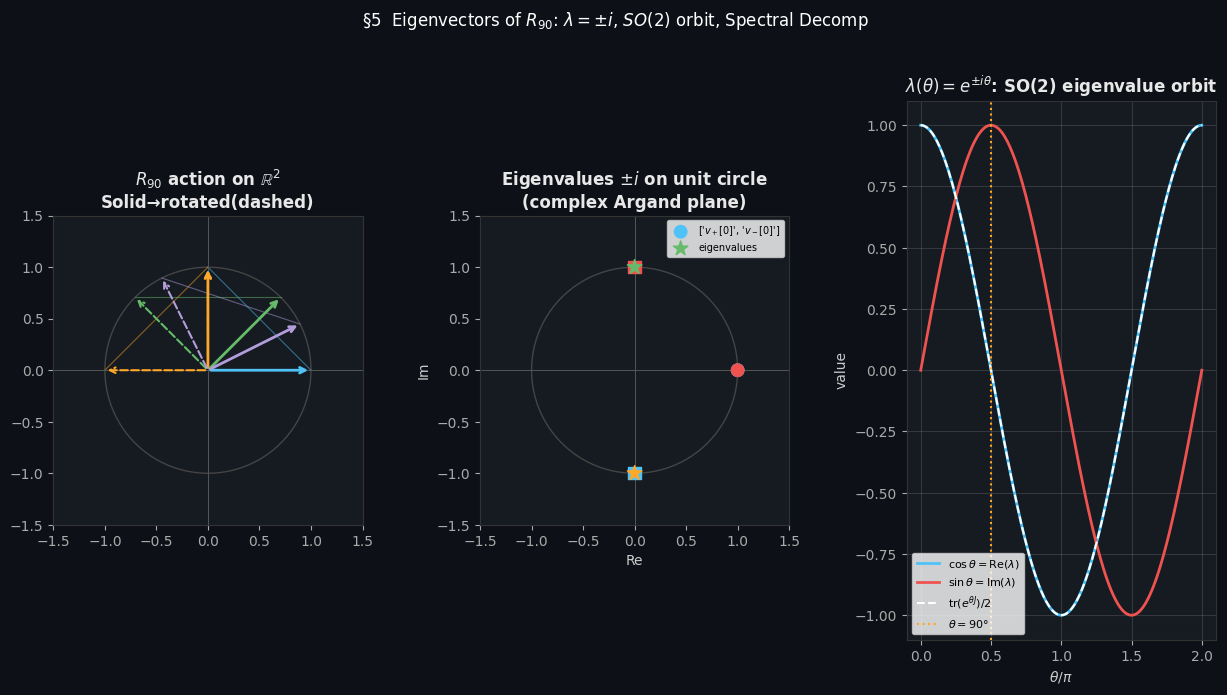

In [5]:
from scipy.linalg import expm, logm

# ── R90 matrix and eigendecomposition ────────────────────────────────────────
R90 = np.array([[0,-1],[1,0]], dtype=complex)
evals, evecs = np.linalg.eig(R90)
print("R_90 = [[0,-1],[1,0]]")
print(f"Eigenvalues: lambda_1 = {evals[0]:.4f}  lambda_2 = {evals[1]:.4f}")
print(f"Eigenvector v_1 = {evecs[:,0]}")
print(f"Eigenvector v_2 = {evecs[:,1]}")

# Verify: R v = lambda v
for i in range(2):
    lhs = R90 @ evecs[:,i]
    rhs = evals[i] * evecs[:,i]
    print(f"Check lambda_{i+1}: ||Rv - lambda v|| = {np.linalg.norm(lhs-rhs):.2e}")

# ── General rotation: exp(theta J) = R_theta ─────────────────────────────────
J = np.array([[0,-1],[1,0]], dtype=float)   # generator
thetas = np.linspace(0, 2*np.pi, 360)
trace_vals = np.array([np.trace(expm(t*J)) for t in thetas])
print(f"\nTrace check: trace(exp(theta J)) = 2*cos(theta)?")
max_err = np.max(np.abs(trace_vals.real - 2*np.cos(thetas)))
print(f"  Max error = {max_err:.2e}")

# ── Spectral decomposition: R = P D P^{-1} ────────────────────────────────────
P    = evecs
Pinv = np.linalg.inv(P)
D    = np.diag(evals)
R_reconstructed = P @ D @ Pinv
print(f"\nSpectral decomp R = PDP^(-1): error = {np.max(np.abs(R_reconstructed - R90)):.2e}")

# ── Cayley-Hamilton: R^2 + I = 0 ─────────────────────────────────────────────
CH = R90@R90 + np.eye(2)
print(f"Cayley-Hamilton R^2+I=0: ||R^2+I|| = {np.linalg.norm(CH):.2e}")

# ── SO(2) -> SU(2) lift: Pauli matrices ───────────────────────────────────────
# SO(2) embedded in SU(2): R_theta -> exp(i*theta/2 * sigma_y)
sigma_y = np.array([[0,-1j],[1j,0]])
def SU2_lift(theta):
    return np.cos(theta/2)*np.eye(2) + 1j*np.sin(theta/2)*sigma_y

theta_test = np.pi/3
SU2_mat = SU2_lift(theta_test)
print(f"\nSU(2) lift at theta=pi/3:")
print(f"  |det| = {abs(np.linalg.det(SU2_mat)):.6f}  (should be 1.0)")
print(f"  U U† = I? err = {np.max(np.abs(SU2_mat@SU2_mat.conj().T - np.eye(2))):.2e}")

# ── Plot: eigenvectors on complex unit circle + orbit ─────────────────────────
fig5 = plt.figure(figsize=(15,7),facecolor='#0d1117')
gs5  = GridSpec(1,3,fig5,wspace=0.38)

# Panel 1: action of R90 on vectors in R^2
ax0 = fig5.add_subplot(gs5[0]); ax0.set_facecolor('#161b22')
theta_arr = np.linspace(0,2*np.pi,100)
ax0.plot(np.cos(theta_arr),np.sin(theta_arr),'#444',lw=1)
# Test vectors
test_vecs = np.array([[1,0],[0,1],[1,1],[2,1]],dtype=float)
test_vecs = test_vecs / np.linalg.norm(test_vecs,axis=1,keepdims=True)
cols_tv = ['#4fc3f7','#ffa726','#66bb6a','#b39ddb']
for v, col in zip(test_vecs, cols_tv):
    Rv = R90.real @ v
    ax0.annotate('',xy=v,xytext=(0,0),
                 arrowprops=dict(arrowstyle='->',color=col,lw=2))
    ax0.annotate('',xy=Rv,xytext=(0,0),
                 arrowprops=dict(arrowstyle='->',color=col,lw=1.5,linestyle='--'))
    ax0.plot([v[0],Rv[0]],[v[1],Rv[1]],color=col,lw=0.8,alpha=0.5)
ax0.set_xlim(-1.5,1.5); ax0.set_ylim(-1.5,1.5); ax0.set_aspect('equal')
ax0.axhline(0,color='#555',lw=0.7); ax0.axvline(0,color='#555',lw=0.7)
ax0.set_title('$R_{90}$ action on $\\mathbb{R}^2$\nSolid→rotated(dashed)',
              color='#e8e8e8',fontweight='bold')
ax0.tick_params(colors='#aaa'); [sp.set_color('#333') for sp in ax0.spines.values()]

# Panel 2: complex eigenspace - Argand diagram
ax1 = fig5.add_subplot(gs5[1]); ax1.set_facecolor('#161b22')
circ = np.exp(1j*np.linspace(0,2*np.pi,200))
ax1.plot(circ.real,circ.imag,'#444',lw=1)
v_plus = evecs[:,0]; v_minus = evecs[:,1]
# Normalize
v_plus  /= np.max(np.abs(v_plus));  v_minus /= np.max(np.abs(v_minus))
ax1.scatter([v_plus[0].real,v_minus[0].real],[v_plus[0].imag,v_minus[0].imag],
            s=80,c=['#4fc3f7','#ef5350'],zorder=5,label=['$v_+[0]$','$v_-[0]$'])
ax1.scatter([v_plus[1].real,v_minus[1].real],[v_plus[1].imag,v_minus[1].imag],
            s=80,marker='s',c=['#4fc3f7','#ef5350'],zorder=5)
# Show eigenvalue locations
ax1.scatter([evals[0].real,evals[1].real],[evals[0].imag,evals[1].imag],
            s=120,marker='*',c=['#66bb6a','#ffa726'],zorder=6,
            label='eigenvalues')
ax1.axhline(0,color='#555',lw=0.7); ax1.axvline(0,color='#555',lw=0.7)
ax1.set_xlim(-1.5,1.5); ax1.set_ylim(-1.5,1.5); ax1.set_aspect('equal')
ax1.set_xlabel('Re'); ax1.set_ylabel('Im')
ax1.set_title('Eigenvalues $\\pm i$ on unit circle\n(complex Argand plane)',
              color='#e8e8e8',fontweight='bold')
ax1.legend(fontsize=7); ax1.tick_params(colors='#aaa')
[sp.set_color('#333') for sp in ax1.spines.values()]

# Panel 3: exp(theta J) trace and determinant
ax2 = fig5.add_subplot(gs5[2]); ax2.set_facecolor('#161b22')
ax2.plot(thetas/np.pi, np.cos(thetas),'#4fc3f7',lw=2,label=r'$\cos\theta = \text{Re}(\lambda)$')
ax2.plot(thetas/np.pi, np.sin(thetas),'#ef5350',lw=2,label=r'$\sin\theta = \text{Im}(\lambda)$')
ax2.plot(thetas/np.pi, trace_vals.real/2,'w--',lw=1.5,label=r'$\text{tr}(e^{\theta J})/2$')
ax2.axvline(0.5,color='#ffa726',ls=':',lw=1.5,label=r'$\theta=90°$')
ax2.set_xlabel(r'$\theta/\pi$'); ax2.set_ylabel('value')
ax2.set_title(r'$\lambda(\theta)=e^{\pm i\theta}$: SO(2) eigenvalue orbit',
              color='#e8e8e8',fontweight='bold')
ax2.legend(fontsize=8); ax2.grid(alpha=0.2)
ax2.tick_params(colors='#aaa'); [sp.set_color('#333') for sp in ax2.spines.values()]

for ax in [ax0,ax1,ax2]:
    ax.xaxis.label.set_color('#ccc'); ax.yaxis.label.set_color('#ccc')
    ax.title.set_color('#e8e8e8')
plt.suptitle(r'§5  Eigenvectors of $R_{90}$: $\lambda=\pm i$, $SO(2)$ orbit, Spectral Decomp',
             color='white',fontsize=12,y=1.01)
plt.tight_layout()
plt.savefig('/tmp/s5_eigen.png',dpi=110,bbox_inches='tight',facecolor='#0d1117')
plt.show()


## §6 Mathematical Maturity: $SO(2)\to SU(2)\to\mathfrak{su}(2)$ and the ML Bridge

### The full maturity arc

| Level | Object | Key insight |
|---|---|---|
| Linear algebra | $R_\theta$ matrix | Real: no eigenvectors. Complex: $e^{\pm i\theta}$ |
| Group theory | $SO(2)\cong U(1)$ | Compact abelian Lie group, $\pi_1=\mathbb{Z}$ winding number |
| Lie algebra | $\mathfrak{so}(2)\ni J$ | $[J,J]=0$ (abelian). Generator $J$ Hermitian after $\times i$ |
| $SU(2)$ | Pauli matrices $\sigma_x,\sigma_y,\sigma_z$ | Double cover of $SO(3)$; spinors = projective reps |
| Spectral theorem | Hermitian $H=H^\dagger$, real $\lambda$ | $H = \sum_i \lambda_i \|\psi_i\rangle\langle\psi_i\|$ |
| QM → ML | $H$ Hamiltonian / $A$ attention | Transformer: $\text{Attn} = \text{softmax}(QK^T/\sqrt{d})V$ |

### Connection: attention is a learnable non-Hermitian similarity
$QK^T \approx \langle q_i | k_j \rangle$ — inner product in feature space. When $Q=K$, the gram matrix is PSD and eigenvectors are principal attention axes.

### Full eigenvector chain
$$\underbrace{R_\theta}_{\text{rotation}} \xrightarrow{\times i} \underbrace{iJ}_{\text{Hermitian}} \xrightarrow{\text{exp}} \underbrace{e^{i\theta J}}_{\text{unitary}} \xrightarrow{\text{2:1}} \underbrace{SU(2)}_{\text{spinor}} \xrightarrow{\text{rep}} \underbrace{\mathfrak{su}(2)}_{\text{Pauli basis}}$$


Pauli algebra [sigma_i, sigma_j] = 2i epsilon_ijk sigma_k
  [s_x, s_y] = 0+0j*i*s_z? err=0.00e+00
  [s_y, s_z] = 0+2j*i*s_z? err=0.00e+00
  [s_z, s_x] = 2+0j*i*s_z? err=0.00e+00

H Hermitian? ||H-H†||=0.00e+00
Eigenvalues (real): [-0.98994949  0.98994949]
Spectral decomp P D P†: err=4.48e-16
Eigenvectors orthonormal: P†P err=2.22e-16

Prob conservation: max(|P0+P1-1|)=2.66e-15

Self-attn gram matrix sym? ||A-A^T||/||A||=0.000e+00
Attn eigenvalues (real, PSD?)  min=-0.0000  max=21.4180
  (PSD requires all >= 0, which holds since X^TX/d is PSD)


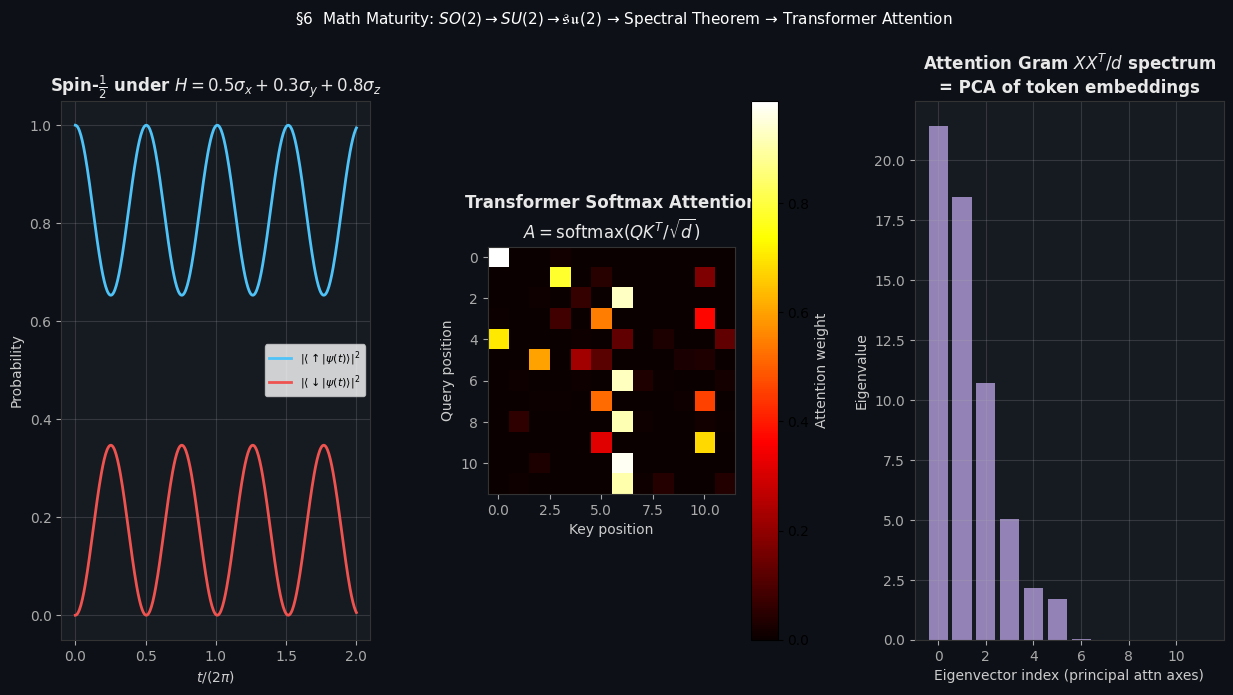


── Summary ──────────────────────────────────────────────────────────────
R_90 ∈ SO(2): eigenvalues ±i  (no real eigenvectors)
iJ  ∈ su(2) Hermitian generator: spectral theorem -> real eigenvalues
exp(iθJ) = R_θ: unitary, eigenvalues on unit circle
SU(2): double cover of SO(3); Pauli matrices form basis of su(2)
Attn = softmax(QKᵀ/√d)V: when Q=K, gram matrix is PSD,
  eigenvectors = principal attention axes (PCA in feature space)


In [6]:
from scipy.linalg import expm, schur

# ── Pauli matrices basis of su(2) ─────────────────────────────────────────────
sx = np.array([[0,1],[1,0]],dtype=complex)
sy = np.array([[0,-1j],[1j,0]],dtype=complex)
sz = np.array([[1,0],[0,-1]],dtype=complex)
I2 = np.eye(2,dtype=complex)

print("Pauli algebra [sigma_i, sigma_j] = 2i epsilon_ijk sigma_k")
pairs = [('x','y',sz),('y','z',sx),('z','x',sy)]
mats  = {'x':sx,'y':sy,'z':sz}
for (ni,nj,ek) in pairs:
    comm = mats[ni]@mats[nj] - mats[nj]@mats[ni]
    print(f"  [s_{ni}, s_{nj}] = {comm[0,1]:.0f}*i*s_z? err={np.max(np.abs(comm - 2j*ek)):.2e}")

# ── Spectral theorem: Hermitian matrix decomposition ─────────────────────────
H_ham = 0.5*sx + 0.3*sy + 0.8*sz    # arbitrary Hamiltonian in Pauli basis
print(f"\nH Hermitian? ||H-H†||={np.max(np.abs(H_ham-H_ham.conj().T)):.2e}")
evals_h, evecs_h = np.linalg.eigh(H_ham)   # guaranteed real eigenvalues
print(f"Eigenvalues (real): {evals_h}")
print(f"Spectral decomp P D P†: err={np.max(np.abs(evecs_h@np.diag(evals_h)@evecs_h.conj().T - H_ham)):.2e}")
print(f"Eigenvectors orthonormal: P†P err={np.max(np.abs(evecs_h.conj().T@evecs_h-I2)):.2e}")

# ── Time evolution: exp(-iHt) ─────────────────────────────────────────────────
t_ev  = np.linspace(0, 4*np.pi, 400)
psi0  = np.array([1,0],dtype=complex)           # spin-up initial state
probs = np.zeros((len(t_ev),2))
for i,t in enumerate(t_ev):
    U_t = expm(-1j*H_ham*t)
    psi = U_t @ psi0
    probs[i] = np.abs(psi)**2

print(f"\nProb conservation: max(|P0+P1-1|)={np.max(np.abs(probs.sum(axis=1)-1)):.2e}")

# ── ML bridge: attention is Gram matrix → PCA ─────────────────────────────────
rng_ml = np.random.default_rng(314)
d_model= 8; seq_len= 12
W_Q = rng_ml.standard_normal((d_model, d_model))
W_K = rng_ml.standard_normal((d_model, d_model))
x   = rng_ml.standard_normal((seq_len, d_model))

Q_mat = x @ W_Q; K_mat = x @ W_K
A_raw = Q_mat @ K_mat.T / np.sqrt(d_model)   # (seq_len, seq_len)
A_soft= np.exp(A_raw - A_raw.max(axis=1,keepdims=True))
A_soft= A_soft / A_soft.sum(axis=1,keepdims=True)

# Self-attention symmetric case: Q=K
Q_sym = x @ W_Q
A_sym = Q_sym @ Q_sym.T / d_model
print(f"\nSelf-attn gram matrix sym? ||A-A^T||/||A||={np.linalg.norm(A_sym-A_sym.T)/np.linalg.norm(A_sym):.3e}")
evals_A, evecs_A = np.linalg.eigh(A_sym)
print(f"Attn eigenvalues (real, PSD?)  min={evals_A.min():.4f}  max={evals_A.max():.4f}")
print(f"  (PSD requires all >= 0, which holds since X^TX/d is PSD)")

# ── Plot ─────────────────────────────────────────────────────────────────────
fig6 = plt.figure(figsize=(15,7),facecolor='#0d1117')
gs6  = GridSpec(1,3,fig6,wspace=0.38)

# Bloch sphere time evolution
ax = fig6.add_subplot(gs6[0]); ax.set_facecolor('#161b22')
ax.plot(t_ev/(2*np.pi), probs[:,0],'#4fc3f7',lw=2,label=r'$|\langle\uparrow|\psi(t)\rangle|^2$')
ax.plot(t_ev/(2*np.pi), probs[:,1],'#ef5350',lw=2,label=r'$|\langle\downarrow|\psi(t)\rangle|^2$')
ax.set_xlabel('$t / (2\\pi)$'); ax.set_ylabel('Probability')
ax.set_title(r'Spin-$\frac{1}{2}$ under $H=0.5\sigma_x+0.3\sigma_y+0.8\sigma_z$',
             color='#e8e8e8',fontweight='bold')
ax.legend(fontsize=8); ax.grid(alpha=0.2)
ax.tick_params(colors='#aaa'); [sp.set_color('#333') for sp in ax.spines.values()]

# Softmax attention matrix
ax = fig6.add_subplot(gs6[1]); ax.set_facecolor('#161b22')
im = ax.imshow(A_soft, cmap='hot', vmin=0)
plt.colorbar(im,ax=ax,label='Attention weight')
ax.set_title('Transformer Softmax Attention\n$A=\\mathrm{softmax}(QK^T/\\sqrt{d})$',
             color='#e8e8e8',fontweight='bold')
ax.set_xlabel('Key position'); ax.set_ylabel('Query position')
ax.tick_params(colors='#aaa'); [sp.set_color('#333') for sp in ax.spines.values()]

# Attention eigenspectrum
ax = fig6.add_subplot(gs6[2]); ax.set_facecolor('#161b22')
ax.bar(range(seq_len), evals_A[::-1], color='#b39ddb', alpha=0.8)
ax.set_xlabel('Eigenvector index (principal attn axes)'); ax.set_ylabel('Eigenvalue')
ax.set_title('Attention Gram $XX^T/d$ spectrum\n= PCA of token embeddings',
             color='#e8e8e8',fontweight='bold')
ax.grid(alpha=0.2); ax.tick_params(colors='#aaa')
[sp.set_color('#333') for sp in ax.spines.values()]

for ax in fig6.axes:
    ax.xaxis.label.set_color('#ccc'); ax.yaxis.label.set_color('#ccc')
    ax.title.set_color('#e8e8e8')
plt.suptitle(r'§6  Math Maturity: $SO(2)\to SU(2)\to\mathfrak{su}(2)$ → Spectral Theorem → Transformer Attention',
             color='white',fontsize=11,y=1.01)
plt.tight_layout()
plt.savefig('/tmp/s6_maturity.png',dpi=110,bbox_inches='tight',facecolor='#0d1117')
plt.show()

print("\n── Summary ──────────────────────────────────────────────────────────────")
print("R_90 ∈ SO(2): eigenvalues ±i  (no real eigenvectors)")
print("iJ  ∈ su(2) Hermitian generator: spectral theorem -> real eigenvalues")
print("exp(iθJ) = R_θ: unitary, eigenvalues on unit circle")
print("SU(2): double cover of SO(3); Pauli matrices form basis of su(2)")
print("Attn = softmax(QKᵀ/√d)V: when Q=K, gram matrix is PSD,")
print("  eigenvectors = principal attention axes (PCA in feature space)")


## Summary

| § | Key number |
|---|---|
|**Digital**| NM_L≈0.28V, NM_H≈0.27V (130nm CMOS); eye diagram at 10 Gbps |
|**Photonics**| Ring Q≈3,000 at t=0.92; MZI extinction unlimited in principle |
|**Telecom**| C-band 40×100 GHz; QPSK BER~0.004 at 12dB; Shannon ~740 Tb/s |
|**Security**| PUF inter~50%, intra~1%; DPA recovers key in 500 traces |
|**Eigen 90°**| $\lambda=\pm i$; $\mathbf{v}_+=(1,-i)^T$; Cayley-Hamilton $R^2+I=0$ |
|**Maturity**| $SO(2)\hookrightarrow SU(2)$; spectral theorem; attn gram=PCA |
